In [10]:
from sympy import Eq, symbols, Function, solve, simplify

x, t, dt, dx, c = symbols('x t dt dx c')
u = Function('u')(t, x)

continuous = Eq(c*u.diff(t) + c*u.diff(x), 0)
continuous

Eq(c*Derivative(u(t, x), t) + c*Derivative(u(t, x), x), 0)

In [11]:
u = symbols('u', cls=Function)
discrete = Eq((u(t+1, x)-u(t, x))/dt + c*((u(t, x-1)-u(t, x))/dx), 0)
discrete

Eq(c*(-u(t, x) + u(t, x - 1))/dx + (-u(t, x) + u(t + 1, x))/dt, 0)

In [12]:
solution = Eq(solve(discrete, u(t+1, x))[0], u(t+1, x))
solution
solve(discrete, u(t+1, x))

[(c*dt*u(t, x) - c*dt*u(t, x - 1) + dx*u(t, x))/dx]

In [19]:
import numpy as np
import matplotlib.pyplot as plt

c = 1
nt = 50
dt = 0.05
nx = 30
dx = 1

u = np.ones(shape=(nx))
u[int(nx/3):int(nx/1.5)] = 2
u

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

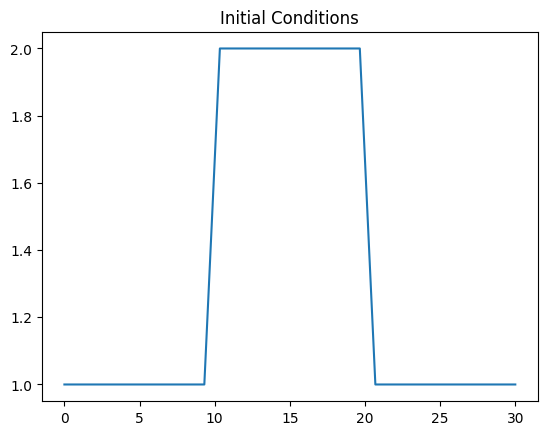

In [20]:
def plot(title=None):
    plt.title(title)
    plt.plot(np.linspace(0, nx, num=nx), u)
    plt.show()
plot(title="Initial Conditions")

$\displaystyle \frac{c dt u{\left(t,x \right)} - c dt u{\left(t,x - 1 \right)} + dx u{\left(t,x \right)}}{dx} = u{\left(t + 1,x \right)}$

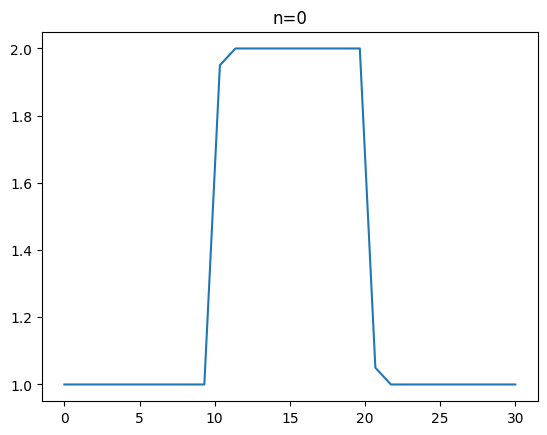

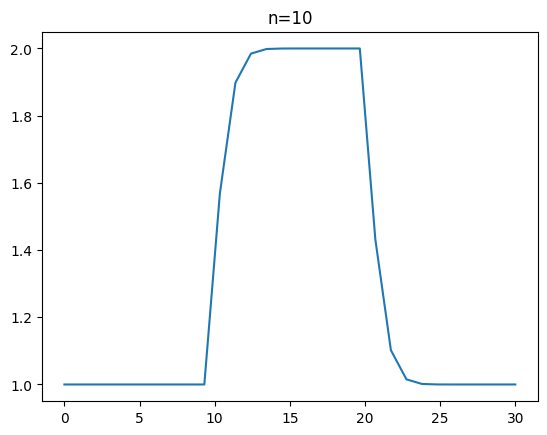

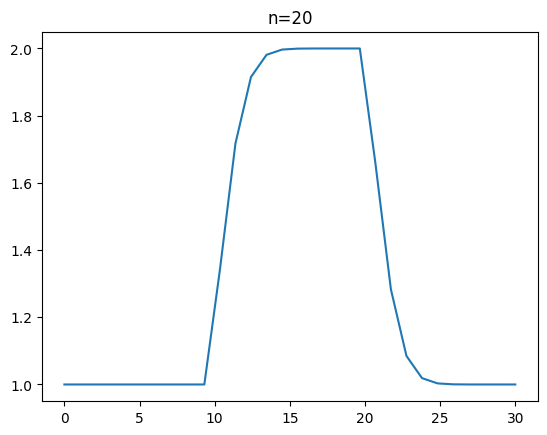

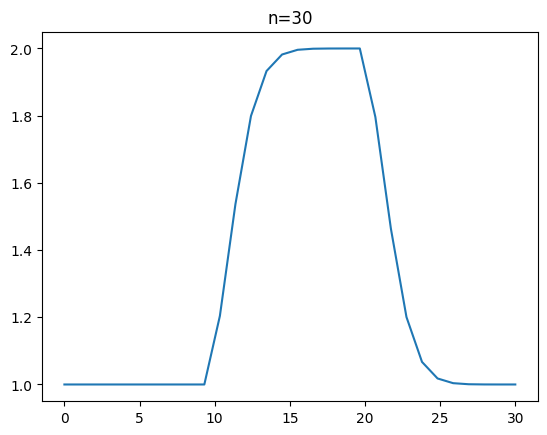

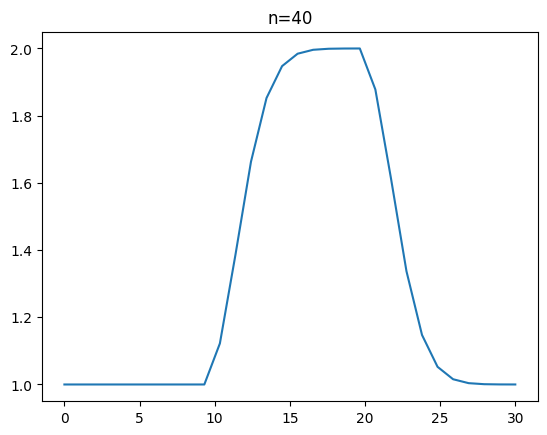

In [21]:
for n in range(nt):
    un = u.copy()
    for i in range(1, nx):
        u[i] = un[i] - c * dt / dx * (un[i] - un[i-1])
    if n % 10 == 0:
        plot(title=f"n={n}")

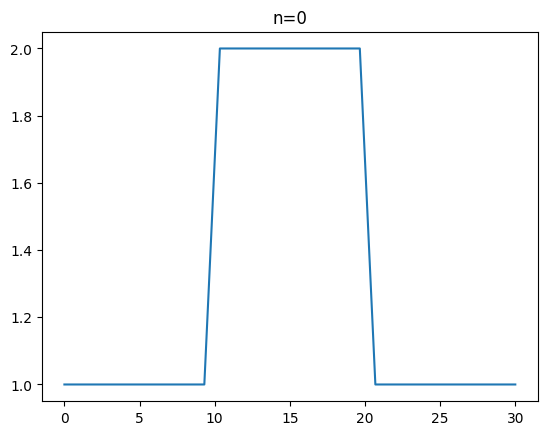

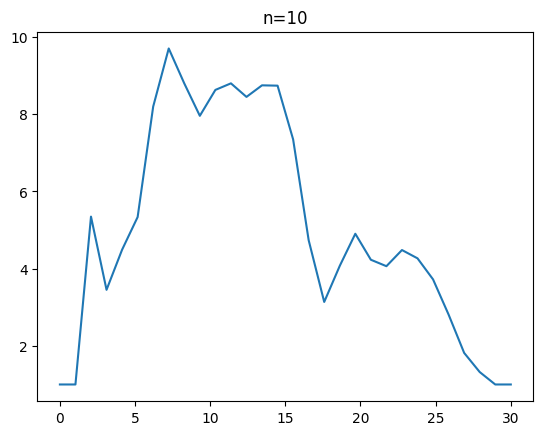

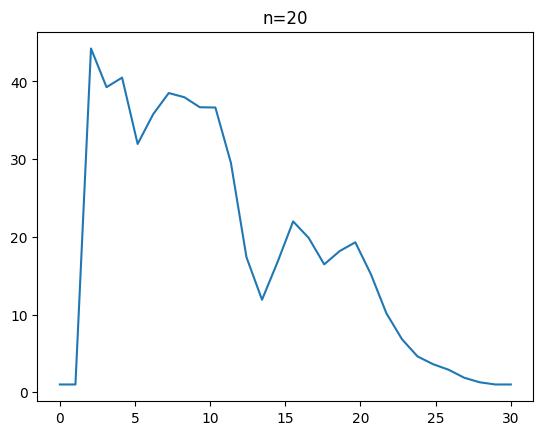

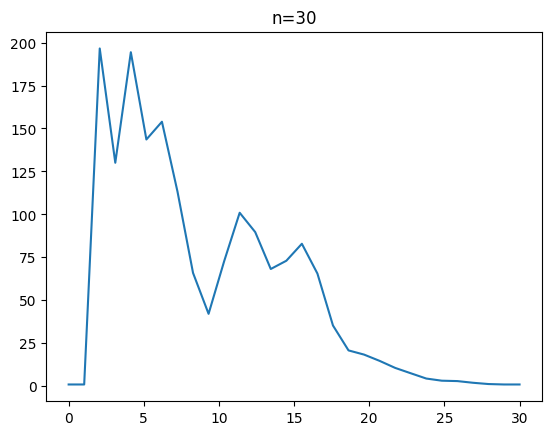

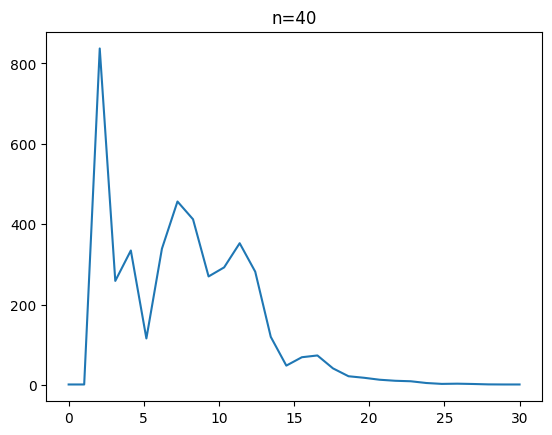

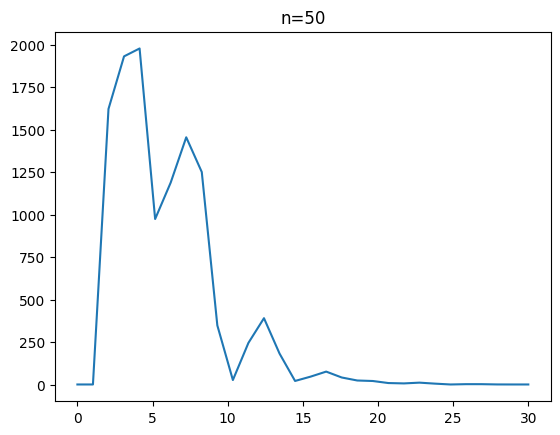

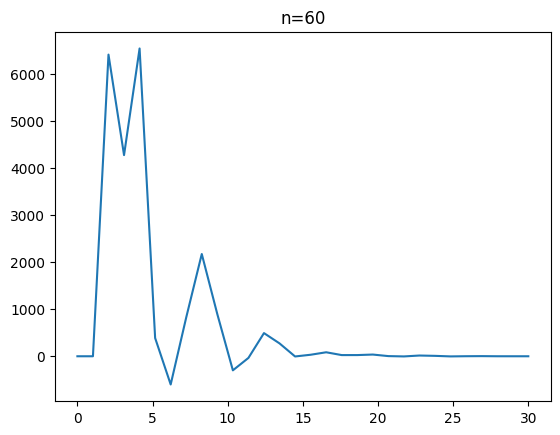

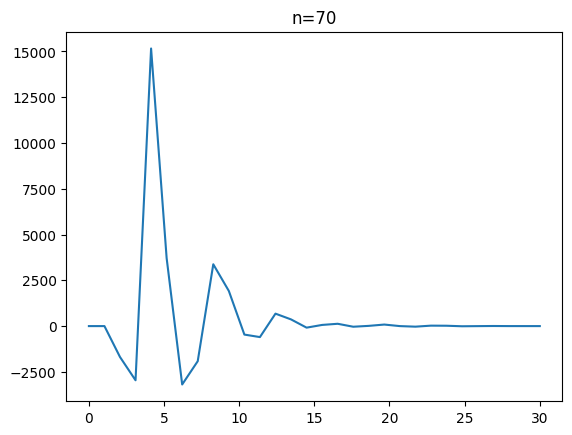

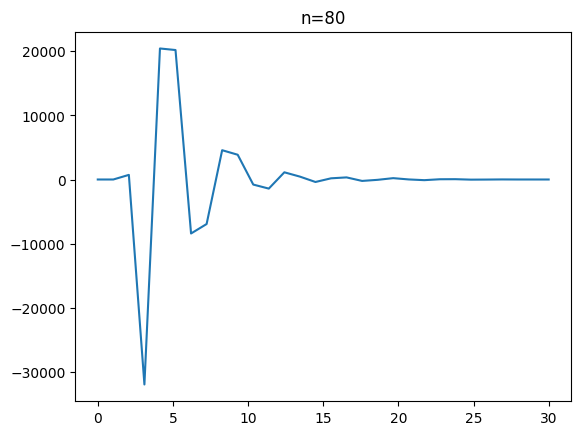

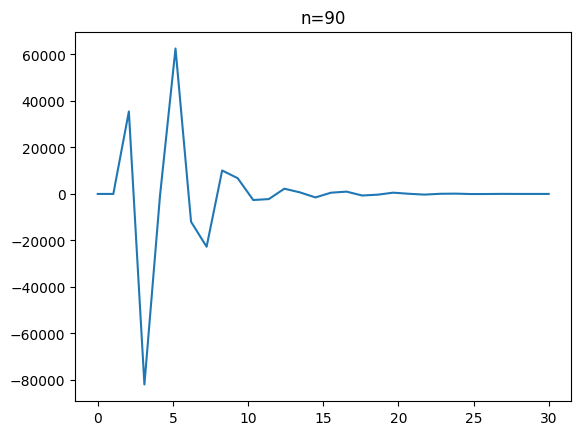

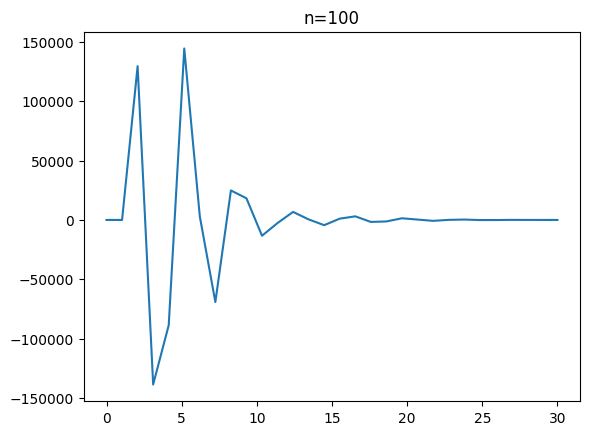

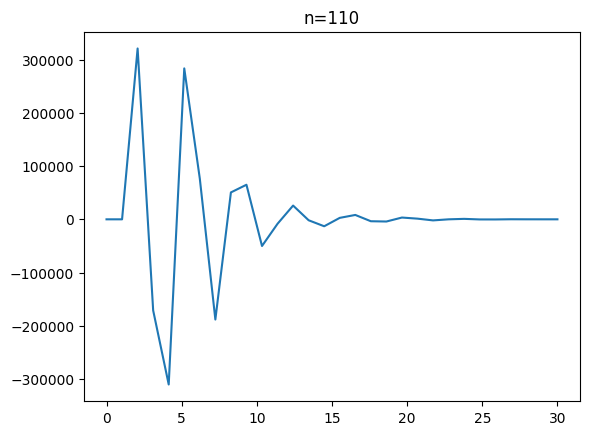

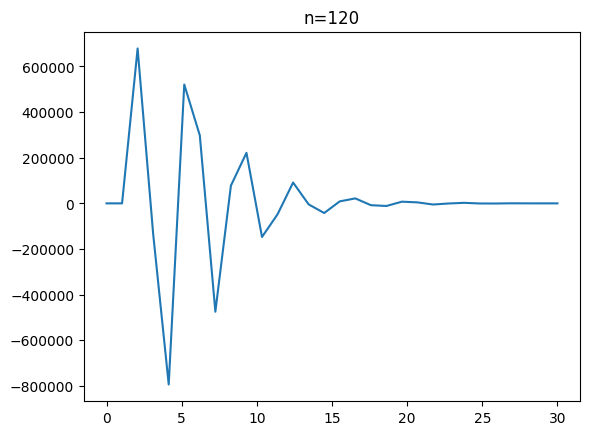

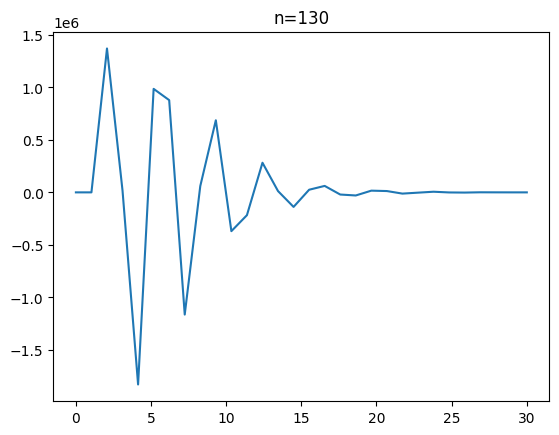

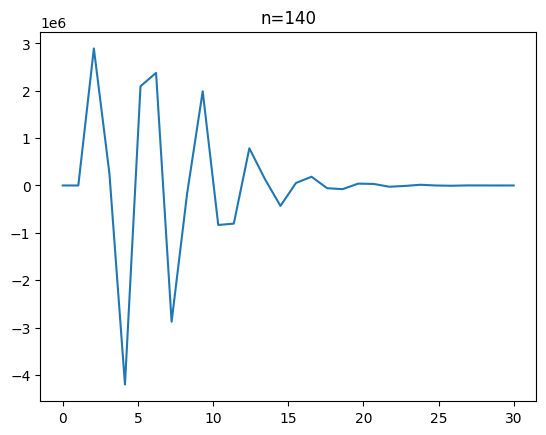

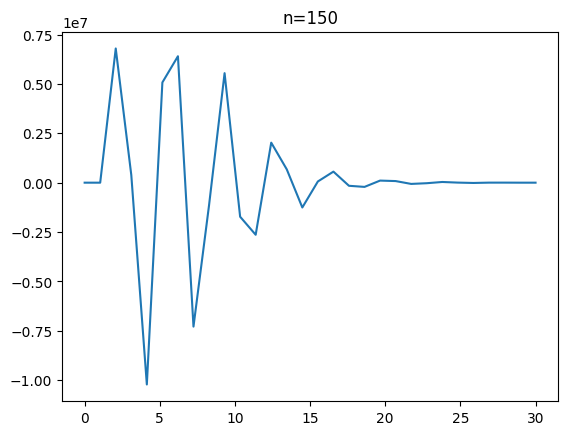

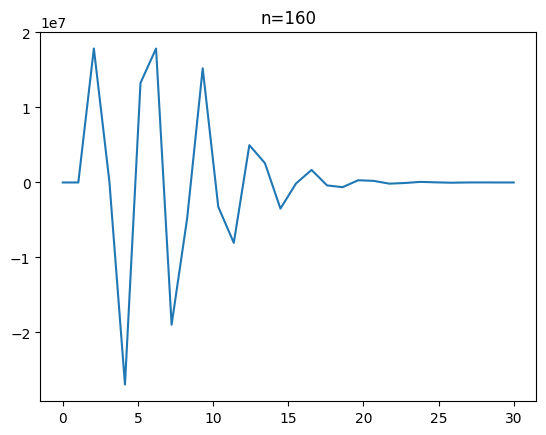

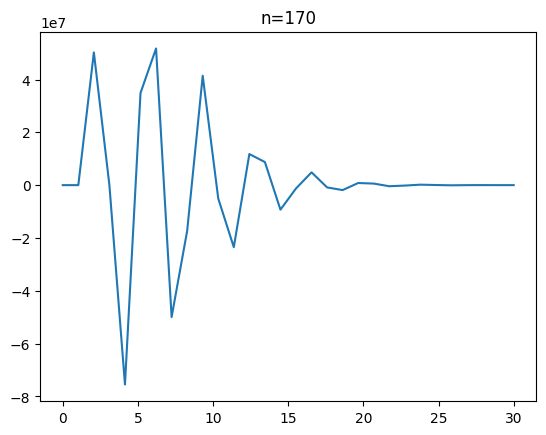

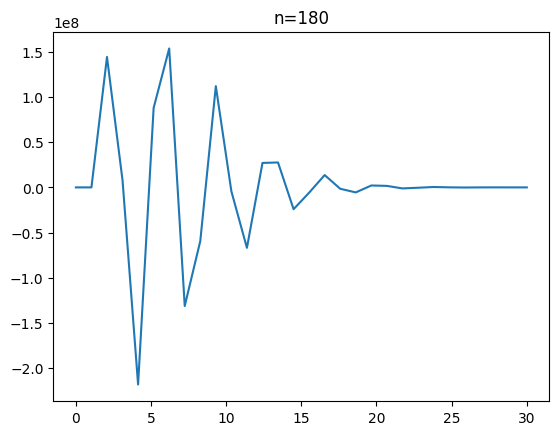

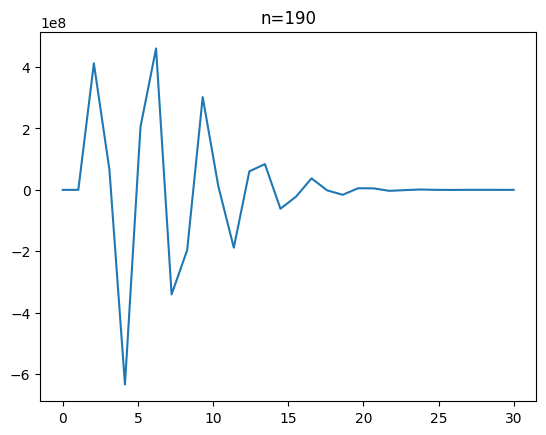

In [22]:
u = np.ones(shape=(nx))
u[int(nx/3):int(nx/1.5)] = 2
nt = 200

for n in range(nt):
    un = u.copy()
    if n % 10 == 0:
        plot(title=f"n={n}")
    for x in range(2, nx-2):
        u[x] = (1/30)*un[x-2] - (13/60)*un[x-1] + (47/50)*un[x] + (9/20)*un[x+1] - (1/20)*un[x+2]